# 1. Knowledge graph를 triple 리스트로 저장
### -> 리스트 안에 튜플을 넣는 방식

In [34]:
triples = [
    ("Excavation", "mayCause", "SafetyRisk"),
    ("Excavation", "mayCause", "Delay"),

    ("ConcretePouring", "mayCause", "QualityIssue"),
    ("ConcretePouring", "mayCause", "WeatherImpact"),

    ("CurtainWallInstallation", "mayCause", "Delay"),
    ("CurtainWallInstallation", "mayCause", "MaterialShortage"),
    ("CurtainWallInstallation", "mayCause", "SafetyRisk"),

    ("SafetyRisk", "solvedBy", "InstallSafetyNet"),
    ("Delay", "solvedBy", "IncreaseLabor"),
    ("Delay", "solvedBy", "RescheduleWork"),
    ("QualityIssue", "solvedBy", "AdditionalInspection"),
    ("WeatherImpact", "solvedBy", "RescheduleWork"),
    ("MaterialShortage", "solvedBy", "ExpediteDelivery"),
]

# 2. subject - relation 을 통해 object 찾기

In [35]:
def find_objects(subject, relation, triples):
    results = []
    for s, r, o in triples:
        if s == subject and r == relation:
            results.append(o)
    return results

# 3. Activate -> Issue

In [36]:
def get_issues(activity, triples):
    return find_objects(activity, "mayCause", triples)

# 4. Issue -> Action

In [37]:
def get_actions(issue, triples):
    return find_objects(issue, "solvedBy", triples)

# 5. Activity -> Issue -> Action

In [38]:
def get_actions_for_activity(activity, triples):
    issues = get_issues(activity, triples)
    actions = []

    for issue in issues:
        issue_actions = get_actions(issue, triples)
        actions.extend(issue_actions)

    actions = list(set(actions))
    return issues, actions

# 6. Practice

In [39]:
activity_name = "CurtainWallInstallation"

issues, actions = get_actions_for_activity(activity_name, triples)

print(f"Activity: {activity_name}")
print("Possible Issues:")
for issue in issues:
    print("-", issue)

print("\nRecommended Actions:")
for action in actions:
    print("-", action)

Activity: CurtainWallInstallation
Possible Issues:
- Delay
- MaterialShortage
- SafetyRisk

Recommended Actions:
- IncreaseLabor
- ExpediteDelivery
- InstallSafetyNet
- RescheduleWork


# 7. Visualization

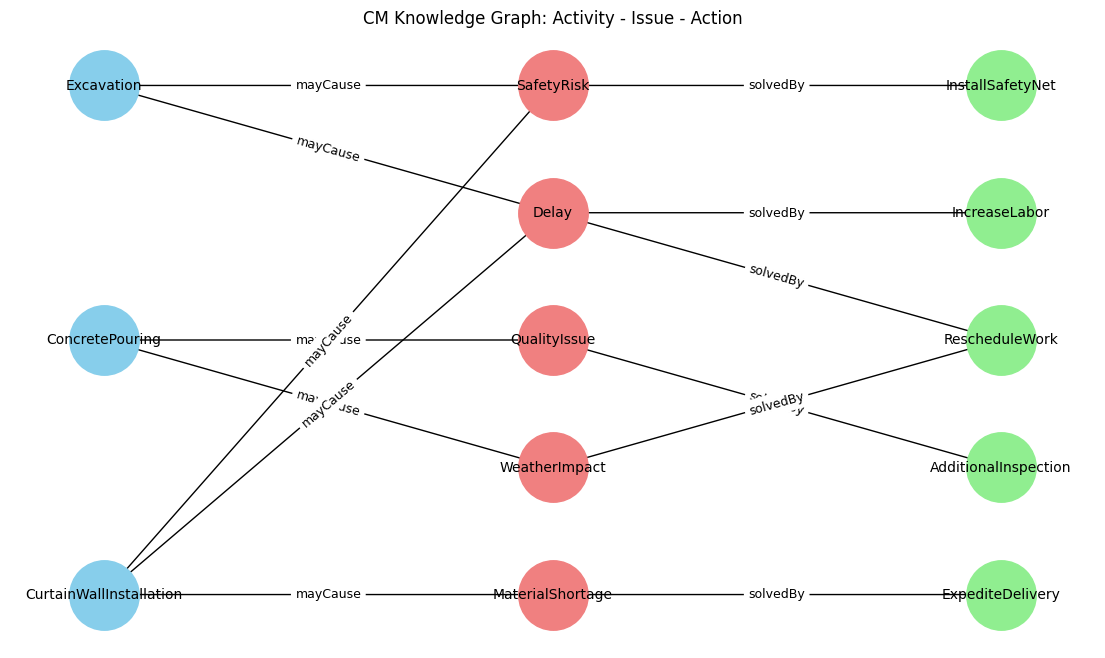

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for s, r, o in triples:
    G.add_edge(s, o, label=r)

activity_nodes = ["Excavation", "ConcretePouring", "CurtainWallInstallation"]
issue_nodes = ["SafetyRisk", "Delay", "QualityIssue", "WeatherImpact", "MaterialShortage"]
action_nodes = ["InstallSafetyNet", "IncreaseLabor", "RescheduleWork", "AdditionalInspection", "ExpediteDelivery"]

pos = {
    "Excavation": (0, 2),
    "ConcretePouring": (0, 1),
    "CurtainWallInstallation": (0, 0),

    "SafetyRisk": (2, 2),
    "Delay": (2, 1.5),
    "QualityIssue": (2, 1),
    "WeatherImpact": (2, 0.5),
    "MaterialShortage": (2, 0),

    "InstallSafetyNet": (4, 2),
    "IncreaseLabor": (4, 1.5),
    "RescheduleWork": (4, 1),
    "AdditionalInspection": (4, 0.5),
    "ExpediteDelivery": (4, 0),
}

plt.figure(figsize=(14, 8))

nx.draw_networkx_nodes(G, pos, nodelist=activity_nodes, node_color="skyblue", node_size=2500)
nx.draw_networkx_nodes(G, pos, nodelist=issue_nodes, node_color="lightcoral", node_size=2500)
nx.draw_networkx_nodes(G, pos, nodelist=action_nodes, node_color="lightgreen", node_size=2500)

nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")

nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=20)

edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("CM Knowledge Graph: Activity - Issue - Action")
plt.axis("off")
plt.show()

# 8. Reasoning 추가하기

In [42]:
def infer_can_be_handled_by(triples):
    inferred_triples = []

    for s1, r1, o1 in triples:
        if r1 == "mayCause":
            activity = s1
            issue = o1

            for s2, r2, o2 in triples:
                if s2 == issue and r2 == "solvedBy":
                    action = o2
                    new_triple = (activity, "canBeHandledBy", action)

                    if new_triple not in inferred_triples:
                        inferred_triples.append(new_triple)

    return inferred_triples

inferred_triples = infer_can_be_handled_by(triples)

print("\n=== Inferred Triples ===")
for triple in inferred_triples:
    print(triple)


=== Inferred Triples ===
('Excavation', 'canBeHandledBy', 'InstallSafetyNet')
('Excavation', 'canBeHandledBy', 'IncreaseLabor')
('Excavation', 'canBeHandledBy', 'RescheduleWork')
('ConcretePouring', 'canBeHandledBy', 'AdditionalInspection')
('ConcretePouring', 'canBeHandledBy', 'RescheduleWork')
('CurtainWallInstallation', 'canBeHandledBy', 'IncreaseLabor')
('CurtainWallInstallation', 'canBeHandledBy', 'RescheduleWork')
('CurtainWallInstallation', 'canBeHandledBy', 'ExpediteDelivery')
('CurtainWallInstallation', 'canBeHandledBy', 'InstallSafetyNet')


# 9. 기존 triples와 새로 추론한 triples를 합침

In [43]:
all_triples = triples + inferred_triples

# 10. 새 relation 조회 함수

In [44]:
def get_handling_actions(activity, triples):
    return find_objects(activity, "canBeHandledBy", triples)

# 11. TEST

In [45]:
activity_name = "CurtainWallInstallation"
handling_actions = get_handling_actions(activity_name, all_triples)

print(f"\n=== Inferred handling actions for {activity_name} ===")
for action in handling_actions:
    print("-", action)


=== Inferred handling actions for CurtainWallInstallation ===
- IncreaseLabor
- RescheduleWork
- ExpediteDelivery
- InstallSafetyNet


# 12. Visualization

NameError: name 'original_edges' is not defined

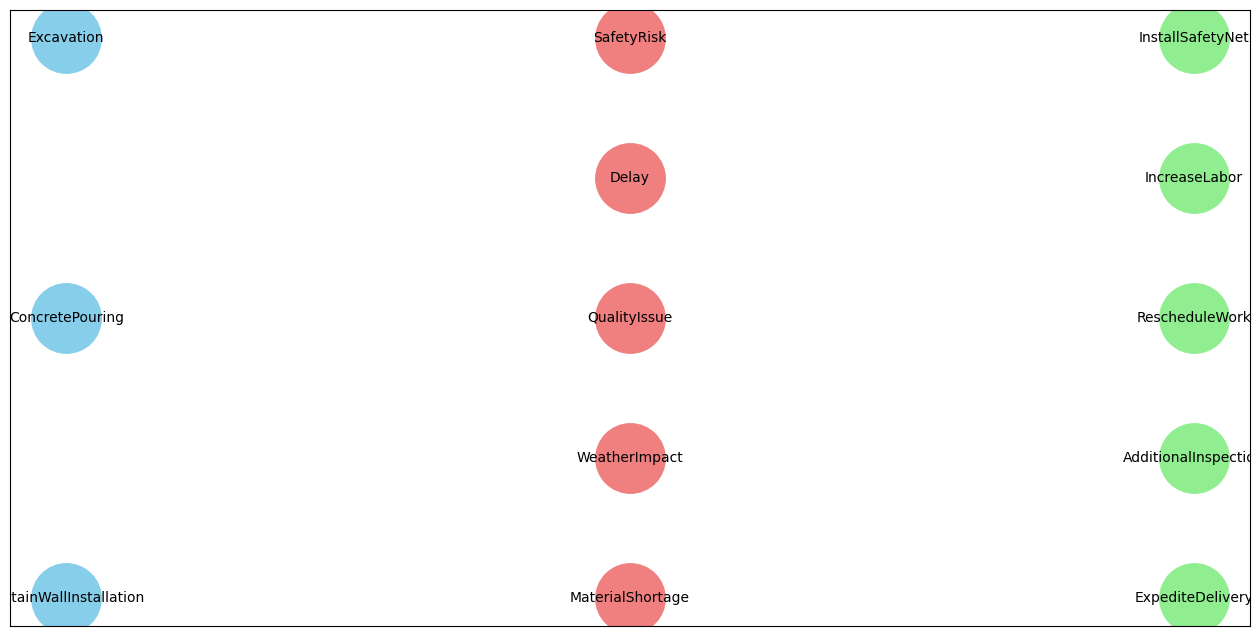

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G2 = nx.DiGraph()

for s, r, o in triples:
    G.add_edge(s, o, label=r)

for s, r, o in all_triples:
    G2.add_edge(s, o, label=r)

activity_nodes = ["Excavation", "ConcretePouring", "CurtainWallInstallation"]
issue_nodes = ["SafetyRisk", "Delay", "QualityIssue", "WeatherImpact", "MaterialShortage"]
action_nodes = ["InstallSafetyNet", "IncreaseLabor", "RescheduleWork", "AdditionalInspection", "ExpediteDelivery"]

pos = {
    "Excavation": (0, 2),
    "ConcretePouring": (0, 1),
    "CurtainWallInstallation": (0, 0),

    "SafetyRisk": (2, 2),
    "Delay": (2, 1.5),
    "QualityIssue": (2, 1),
    "WeatherImpact": (2, 0.5),
    "MaterialShortage": (2, 0),

    "InstallSafetyNet": (4, 2),
    "IncreaseLabor": (4, 1.5),
    "RescheduleWork": (4, 1),
    "AdditionalInspection": (4, 0.5),
    "ExpediteDelivery": (4, 0),
}

plt.figure(figsize=(16, 8))

nx.draw_networkx_nodes(G2, pos, nodelist=activity_nodes, node_color="skyblue", node_size=2500)
nx.draw_networkx_nodes(G2, pos, nodelist=issue_nodes, node_color="lightcoral", node_size=2500)
nx.draw_networkx_nodes(G2, pos, nodelist=action_nodes, node_color="lightgreen", node_size=2500)


nx.draw_networkx_labels(G2, pos, font_size=10, font_color="black")

original_edges = [(s, o) for s, r, o in triples]
inferred_edges = [(s, o) for s, r, o in inferred_triples]

nx.draw_networkx_edges(
    G2,
    pos,
    edgelist=original_edges,
    arrows=True,
    arrowstyle="->",
    arrowsize=20,
    width=2
)

nx.draw_networkx_edges(
    G2,
    pos,
    edgelist=inferred_edges,
    arrows=True,
    arrowstyle="->",
    arrowsize=20,
    width=2,
    style="dashed"
)


original_edge_labels = {(s, o): r for s, r, o in triples}
inferred_edge_labels = {(s, o): r for s, r, o in inferred_triples}

nx.draw_networkx_edge_labels(
    G2,
    pos,
    edge_labels=original_edge_labels,
    font_size=9
)

nx.draw_networkx_edge_labels(
    G2,
    pos,
    edge_labels=inferred_edge_labels,
    font_size=9,
    font_color="blue"
)

plt.title("CM Knowledge Graph with Reasoning")
plt.axis("off")
plt.show()